In [1]:
import xgi
import numpy as np
import sys
import os
# __file__ is not defined in Jupyter, use current working directory instead
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'edge_rewiring')))
from sod.simpliciality import edit_simpliciality, face_edit_simpliciality, simplicial_fraction

In [5]:
from edge_rewiring import model_generation
# print(model_generation.approximate_C_upperbound(num_node=10, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=20, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=25, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=50, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=100, min_size=2, max_size=10, num_max_hyperedge=10))
print(model_generation.approximate_C_upperbound(num_node=200, min_size=2, max_size=7, num_max_hyperedge=30))
print(model_generation.approximate_C_upperbound(num_node=1000, min_size=2, max_size=7, num_max_hyperedge=10))
print(model_generation.approximate_C_upperbound(num_node=1000, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=10000, min_size=2, max_size=10, num_max_hyperedge=10))
# print(model_generation.approximate_C_upperbound(num_node=100000, min_size=2, max_size=10, num_max_hyperedge=10))
print(model_generation.possible_combinations(num_node=7, min_size=2, max_size=None))

3362
1320
11143
120


In [4]:
import matplotlib.pyplot as plt
from edge_rewiring import model_generation

H_es = model_generation.model_generation_es(es=0.4, approx_num_C=30, num_max_hyperedge=25,num_node=200, min_size=2, max_size=7, adjust_es=False)
m = H_es.nodes.multi(['degree', 'clustering_coefficient']).asdict()
print(m)
sf = simplicial_fraction(H_es, min_size=2)
es = edit_simpliciality(H_es, min_size=2)
fes = face_edit_simpliciality(H_es, min_size=2)
print(f"Simplicial fraction: {sf}")
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

lst = []
for i in range(500, 10000, 100):
    H_es = model_generation.model_generation_es(es=0.3, approx_num_C=i, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=10)
    m = H_es.nodes.multi(['degree', 'clustering_coefficient']).asdict()
    #print(m)
    es = edit_simpliciality(H_es, min_size=2)
    lst.append(es)
    #print(f"Edit simpliciality: {es}")
    
print(lst)
plt.plot(range(500, 10000, 100), lst, marker='o')
plt.show()

C_distribution: [1 1 1 1 2 1 1 2 1 1 1 2 1 1 1 1 1 1 2 1 1 1 1 1 2]
{0: {'degree': 0, 'clustering_coefficient': 0.0}, 1: {'degree': 0, 'clustering_coefficient': 0.0}, 2: {'degree': 0, 'clustering_coefficient': 0.0}, 3: {'degree': 0, 'clustering_coefficient': 0.0}, 4: {'degree': 0, 'clustering_coefficient': 0.0}, 5: {'degree': 0, 'clustering_coefficient': 0.0}, 6: {'degree': 0, 'clustering_coefficient': 0.0}, 7: {'degree': 0, 'clustering_coefficient': 0.0}, 8: {'degree': 0, 'clustering_coefficient': 0.0}, 9: {'degree': 0, 'clustering_coefficient': 0.0}, 10: {'degree': 0, 'clustering_coefficient': 0.0}, 11: {'degree': 0, 'clustering_coefficient': 0.0}, 12: {'degree': 0, 'clustering_coefficient': 0.0}, 13: {'degree': 0, 'clustering_coefficient': 0.0}, 14: {'degree': 0, 'clustering_coefficient': 0.0}, 15: {'degree': 0, 'clustering_coefficient': 0.0}, 16: {'degree': 0, 'clustering_coefficient': 0.0}, 17: {'degree': 1, 'clustering_coefficient': 0.0}, 18: {'degree': 0, 'clustering_coefficient

In [ ]:
# Note the cmultiedge related methods in xgi are really confusing/weird. Try avoid using it.
# Below is an example of multiedge method not working
H = xgi.Hypergraph()
nodes = [i for i in range(10)]
H.add_nodes_from(nodes)
H.add_edge({1, 10})
H.add_edge({2, 10})
H.add_edge({4,8})
H.add_edge({1, 2, 10})
m = H.nodes.multi(['degree', 'clustering_coefficient'])
print(m.asdict())
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(multiedges=True)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(singletons=True)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,8) # make figures big for easier viewing 
                                        #    (width, height in inches)
# Experiment to find the relationship between edit simpliciality and face edit simpliciality
# for a range of edit simpliciality values
es = []
fes = []
float_range = np.arange(0, 1, 0.02)
for i in range(len(float_range)):
	H = model_generation.edge_rewire_model(edit_simpliciality=float_range[i], approx_num_C=5000, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
	es.append(edit_simpliciality(H, min_size=2))
	fes.append(face_edit_simpliciality(H, min_size=2))
fig, ax = plt.subplots()
ax.plot(es, fes, color='red')

### DO THIS: Add the line of code to plot the trajectory here

ax.set_xlabel('es')
ax.set_ylabel('fes')
# An example of implicit line continuation. Python knows to keep on reading to
#    the next line because the set of parentheses hasn't been closed by the end
#    of the first line.
ax.set_title("velocity vs mass".
             format(es, fes))
plt.show()


AttributeError: module 'edge_rewiring.model_generation' has no attribute 'edge_rewire_model'

selected_edge_idx: 1
Adding edge: [(454, 595), (454, 767), (454, 417), (595, 767), (595, 417), (767, 417), (454, 595, 767), (454, 595, 417), (454, 767, 417), (595, 767, 417), (454, 595, 767, 417)]
selected_edge_idx: 0
Adding edge: [(454, 595), (454, 767), (454, 417), (595, 767), (595, 417), (767, 417), (454, 595, 767), (454, 595, 417), (454, 767, 417), (595, 767, 417), (454, 595, 767, 417)]
selected_edge_idx: 6
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 1546), (109, 1868, 1546), (1421, 109, 1868, 1546)]
selected_edge_idx: 10
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 1546), (109, 1868, 1546), (1421, 109, 1868, 1546)]
selected_edge_idx: 4
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 15

XGIError: Every node must be a member of an edge to avoid divide by zero error!

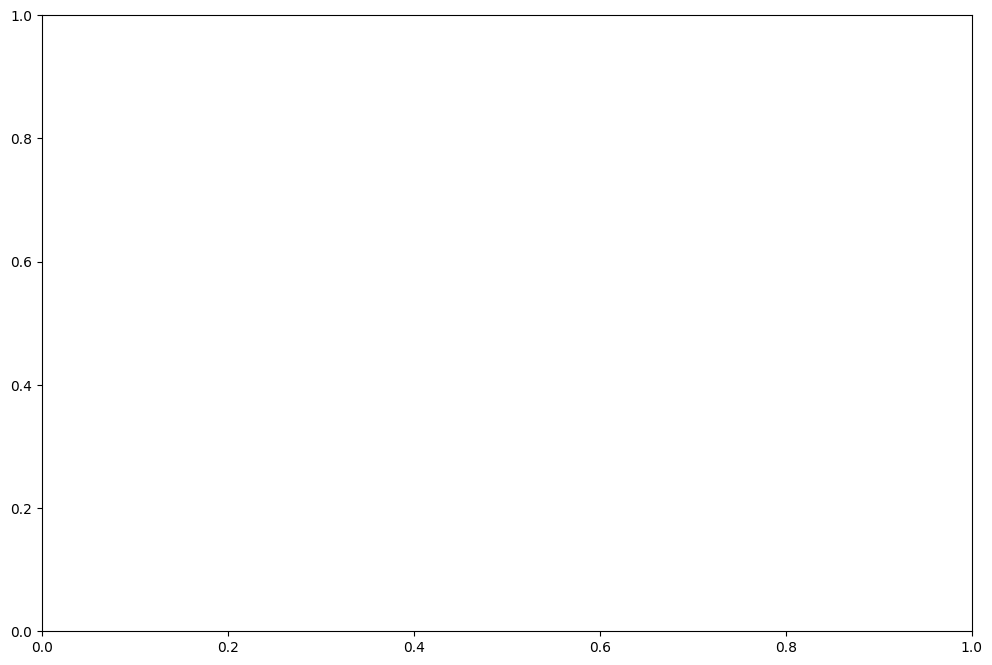

In [ ]:
node = []
cc = []
# Experiment to find the relationship between edit simpliciality and clustering coefficient
fig, ax = plt.subplots()
for i in range(10):
    H = model_generation.edge_rewire_model(0.5, approx_num_C=50, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
    community_clustering = xgi.spectral_clustering(H)
    print(community_clustering)
# 	for idx in range(len(clustering_coefficient)):
# 		node.append(idx)
# 		cc.append(clustering_coefficient[idx])
# ax.scatter(node, cc, color='red')
     



# ### DO THIS: Add the line of code to plot the trajectory here

# ax.set_xlabel('node')
# ax.set_ylabel('cc')
# # An example of implicit line continuation. Python knows to keep on reading to
# #    the next line because the set of parentheses hasn't been closed by the end
# #    of the first line.
# ax.set_title("node vs cc".
#              format(node, cc))
# plt.show()

In [ ]:
print(es)
print(fes)

[nan, nan, nan, nan, nan, nan, nan, 0.13333333333333333, 0.14814814814814814, 0.15789473684210525, 0.19626168224299065, 0.21212121212121213, 0.23529411764705882, 0.2589928057553957, 0.2777777777777778, 0.2937062937062937, 0.31794871794871793, 0.3350253807106599, 0.3564356435643564, 0.3799126637554585, 0.39914163090128757, 0.4147727272727273, 0.4365079365079365, 0.4576923076923077, 0.47619047619047616, 0.5, 0.5171102661596958, 0.5410447761194029, 0.5610687022900763, 0.5811320754716981, 0.6015037593984962, 0.6226415094339622, 0.6428571428571429, 0.6617100371747212, 0.6830188679245283, 0.7034220532319392, 0.7234848484848485, 0.7406015037593985, 0.7604562737642585, 0.7832699619771863, 0.8, 0.8202247191011236, 0.8435114503816794, 0.8609022556390977, 0.8830188679245283, 0.9018867924528302, 0.9201520912547528, 0.9405204460966543, 0.9619771863117871, 0.9811320754716981]
[nan, nan, nan, nan, nan, nan, nan, 0.0, 0.0, 0.0, 0.06933333333333333, 0.10424242424242425, 0.06, 0.13725490196078433, 0.123